##LABSHEET-5

Sakshi(49)

1.Build a keypoint detector and visualizer using SIFT, displaying detected keypoints with their scale and orientation.

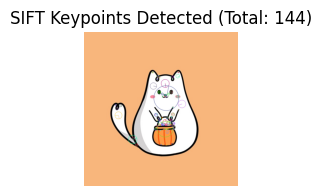

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
import numpy as np
image_path = 'cat.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"Error: Image not found at {image_path}. Please make sure the image file is in the correct directory.")
else:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray_image, None)
    image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(6,2))
    plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f'SIFT Keypoints Detected (Total: {len(keypoints)})')
    plt.axis('off')
    plt.show()

2.Develop an image-matching tool that uses SIFT descriptors to find and draw correspondences between two photos of the same scene.

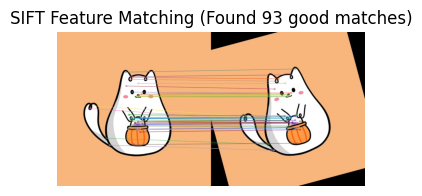

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
import numpy as np
def match_images(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    if img1 is None or img2 is None:
        print("Error loading images. Check your paths.")
        return
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    img_matches = cv2.drawMatches(
        img1, kp1, img2, kp2, good_matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(6,2))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f'SIFT Feature Matching (Found {len(good_matches)} good matches)')
    plt.axis('off')
    plt.show()
cat_path = 'cat.jpg'
cat_img = cv2.imread(cat_path)
if cat_img is not None:
    h, w = cat_img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), 15, 1.0)
    rotated_tiger = cv2.warpAffine(cat_img, M, (w, h))
    cv2.imwrite('cat_rotated.jpg', rotated_tiger)
    match_images(cat_path, 'cat_rotated.jpg')
else:
    print("Please ensure cat.jpg is present in the workspace.")

3. Create a simple panorama stitcher using SIFT feature matching and homography estimation.

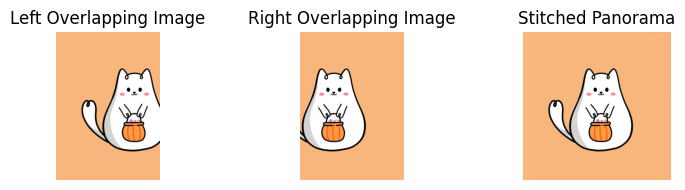

In [ ]:
#SAKSHI (49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
tiger_img = cv2.imread('cat.jpg')
if tiger_img is None:
    print("Error: cat.jpg not found.")
else:
    h, w = tiger_img.shape[:2]
    overlap_width = int(w * 0.6)
    img_left = tiger_img[:, :int(w * 0.7)]
    img_right = tiger_img[:, int(w * 0.3):]
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img_left, None)
    kp2, des2 = sift.detectAndCompute(img_right, None)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    if len(good_matches) > 4:
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
        dst_w = img_left.shape[1] + img_right.shape[1]
        dst_h = img_left.shape[0]
        result_panorama = cv2.warpPerspective(img_right, H, (dst_w, dst_h))
        result_panorama[0:img_left.shape[0], 0:img_left.shape[1]] = img_left
        gray = cv2.cvtColor(result_panorama, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x, y, w_box, h_box = cv2.boundingRect(contours[0])
            result_panorama_cropped = result_panorama[y:y+h_box, x:x+w_box]
        else:
            result_panorama_cropped = result_panorama
        fig, axes = plt.subplots(1, 3, figsize=(8,2))
        axes[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Left Overlapping Image')
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Right Overlapping Image')
        axes[1].axis('off')
        axes[2].imshow(cv2.cvtColor(result_panorama_cropped, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Stitched Panorama')
        axes[2].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough matches found to compute homography.")

4.Build a logo or object locator that finds a reference object inside a cluttered scene using SIFT feature matching

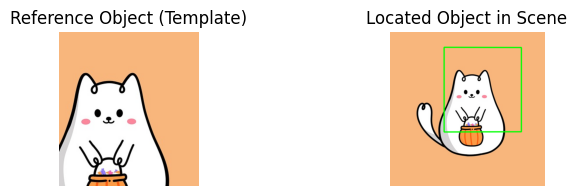

In [ ]:
#SAKSHI (49)
import cv2
import numpy as np
import matplotlib.pyplot as plt
img_scene = cv2.imread('cat.jpg')
if img_scene is not None:
    h_s, w_s = img_scene.shape[:2]
    img_object = img_scene[int(h_s*0.1):int(h_s*0.65), int(w_s*0.35):int(w_s*0.85)]
    sift = cv2.SIFT_create()
    kp_obj, des_obj = sift.detectAndCompute(img_object, None)
    kp_scene, des_scene = sift.detectAndCompute(img_scene, None)
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = flann.knnMatch(des_obj, des_scene, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]
    if len(good_matches) > 10:
        src_pts = np.float32([kp_obj[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        h_o, w_o = img_object.shape[:2]
        pts = np.float32([[0, 0], [0, h_o-1], [w_o-1, h_o-1], [w_o-1, 0]]).reshape(-1, 1, 2)
        dst = cv2.perspectiveTransform(pts, H)
        img_located = img_scene.copy()
        img_located = cv2.polylines(img_located, [np.int32(dst)], True, (0, 255, 0), 3, cv2.LINE_AA)
        fig, axes = plt.subplots(1, 2, figsize=(8,2))
        axes[0].imshow(cv2.cvtColor(img_object, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Reference Object (Template)')
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(img_located, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Located Object in Scene')
        axes[1].axis('off')
        plt.show()
    else:
        print("Not enough feature matches found to localize object.")

5.Develop a HOG based pedestrian or person detector demo on a set of sample images.

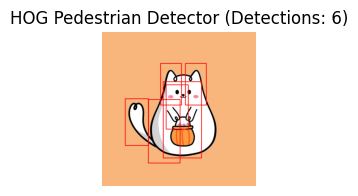

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
img_ped = cv2.imread('cat.jpg')
if img_ped is not None:
    rects, weights = hog.detectMultiScale(img_ped, winStride=(4, 4), padding=(8, 8), scale=1.05)
    img_out = img_ped.copy()
    for (x, y, w, h) in rects:
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 0, 255), 2)
    plt.figure(figsize=(6,2))
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title(f'HOG Pedestrian Detector (Detections: {len(rects)})')
    plt.axis('off')
    plt.show()

6.Create a HOG visualizer that overlays the gradient-orientation histogram grid on top of an image.

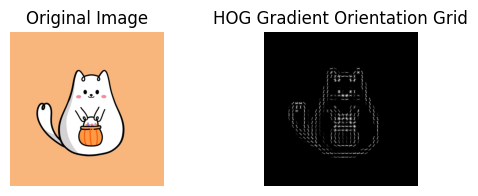

In [ ]:
#SAKSHI (49)
from skimage.feature import hog
from skimage import exposure
import cv2
import matplotlib.pyplot as plt
img_bgr = cv2.imread('cat.jpg')
if img_bgr is not None:
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    features, hog_image = hog(
        img_gray,
        orientations=8,
        pixels_per_cell=(16, 16),
        cells_per_block=(1, 1),
        visualize=True
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    fig, axes = plt.subplots(1, 2, figsize=(6,2))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    axes[1].imshow(hog_image_rescaled, cmap='gray')
    axes[1].set_title('HOG Gradient Orientation Grid')
    axes[1].axis('off')
    plt.show()

7.Build a duplicate / near-duplicate image detector using SIFT feature similarity scoring.

In [ ]:
#SAKSHI (49)
import cv2
import numpy as np
def check_duplicate(img_path1, img_path2, threshold=0.15):
    img1 = cv2.imread(img_path1, cv2.COLOR_BGR2GRAY)
    img2 = cv2.imread(img_path2, cv2.COLOR_BGR2GRAY)
    if img1 is None or img2 is None: return 0.0
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    if des1 is None or des2 is None: return 0.0
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    score = len(good) / max(len(kp1), len(kp2))
    return score
score_self = check_duplicate('cat.jpg', 'cat.jpg')
score_rotated = check_duplicate('cat.jpg', 'cat_rotated.jpg')
print(f"Self-Similarity Score (Exact Duplicate): {score_self:.4f}")
print(f"Similarity Score (Rotated Version): {score_rotated:.4f}")

Self-Similarity Score (Exact Duplicate): 1.0000
Similarity Score (Rotated Version): 0.3944


8.Develop a rotation/scale invariance tester that verifies SIFT keypoints remain consistent under image transformations.

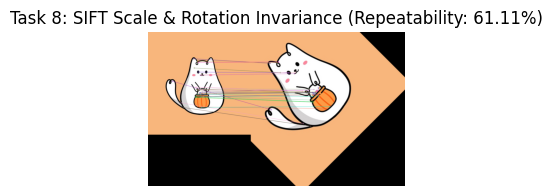

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
img_base = cv2.imread('cat.jpg')
h, w = img_base.shape[:2]
M = cv2.getRotationMatrix2D((w/2, h/2), 45, 1.5)
img_transformed = cv2.warpAffine(img_base, M, (int(w*1.5), int(h*1.5)))
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img_base, None)
kp2, des2 = sift.detectAndCompute(img_transformed, None)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]
repeatability = (len(good) / len(kp1)) * 100 if len(kp1) > 0 else 0.0
img_invariance_matches = cv2.drawMatches(
    img_base, kp1, img_transformed, kp2, good[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(6,2))
plt.imshow(cv2.cvtColor(img_invariance_matches, cv2.COLOR_BGR2RGB))
plt.title(f'Task 8: SIFT Scale & Rotation Invariance (Repeatability: {repeatability:.2f}%)')
plt.axis('off')
plt.show()

9.Create a simple image-retrieval system that ranks a small image database by SIFT feature similarity to a query image.

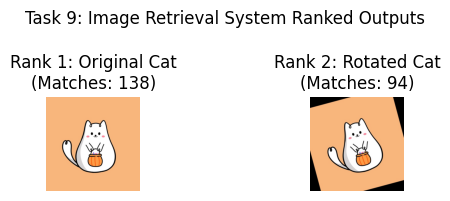

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
import os
database = {
    'Original Cat': 'cat.jpg',
    'Rotated Cat': 'cat_rotated.jpg'
}
query_img_path = 'cat.jpg'
query_img = cv2.imread(query_img_path, cv2.IMREAD_GRAYSCALE)
sift = cv2.SIFT_create()
kp_q, des_q = sift.detectAndCompute(query_img, None)
results = []
bf = cv2.BFMatcher()
for name, path in database.items():
    db_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if db_img is None:
        continue
    kp_db, des_db = sift.detectAndCompute(db_img, None)
    if des_db is None:
        continue
    matches = bf.knnMatch(des_q, des_db, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
    results.append((name, len(good_matches)))
results = sorted(results, key=lambda x: x[1], reverse=True)
fig, axes = plt.subplots(1, len(results), figsize=(6, 2))
if len(results) == 1:
    axes = [axes]
for idx, (name, score) in enumerate(results):
    img_path = database[name]
    img = cv2.imread(img_path)
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Rank {idx+1}: {name}\n(Matches: {score})')
    axes[idx].axis('off')
plt.suptitle('Task 9: Image Retrieval System Ranked Outputs', fontsize=12)
plt.tight_layout()
plt.show()

10.Build a benchmarking tool comparing SIFT versus HOG descriptors on a basic object-recognition task.

In [ ]:
#SAKSHI (49)
import time
import cv2
from skimage.feature import hog
img_bench = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
if img_bench is not None:
    start_time = time.time()
    sift = cv2.SIFT_create()
    kp, des_sift = sift.detectAndCompute(img_bench, None)
    sift_time = time.time() - start_time
    start_time = time.time()
    features_hog = hog(
        img_bench,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )
    hog_time = time.time() - start_time
    print("SIFT vs HOG Descriptor Extraction Benchmark:")
    print(f"- SIFT: Found {len(kp)} features in {sift_time:.4f} seconds.")
    print(f"- HOG: Extracted descriptor vector of size {features_hog.size} in {hog_time:.4f} seconds.")

SIFT vs HOG Descriptor Extraction Benchmark:
- SIFT: Found 138 features in 0.1588 seconds.
- HOG: Extracted descriptor vector of size 224676 in 0.2937 seconds.


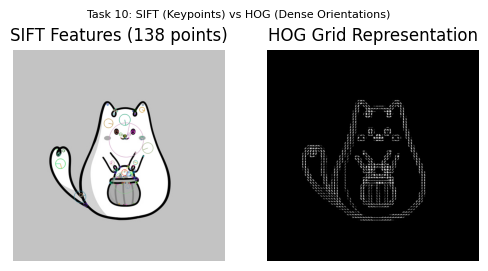

In [ ]:
#SAKSHI (49)
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
img_bench_gray = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
if img_bench_gray is not None:
    sift = cv2.SIFT_create()
    kp_bench = sift.detect(img_bench_gray, None)
    img_sift_pts = cv2.drawKeypoints(img_bench_gray, kp_bench, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    _, hog_vis = hog(
        img_bench_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    hog_vis_rescaled = exposure.rescale_intensity(hog_vis, in_range=(0, 10))
    fig, axes = plt.subplots(1, 2, figsize=(6,3))
    axes[0].imshow(cv2.cvtColor(img_sift_pts, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'SIFT Features ({len(kp_bench)} points)')
    axes[0].axis('off')
    axes[1].imshow(hog_vis_rescaled, cmap='gray')
    axes[1].set_title('HOG Grid Representation')
    axes[1].axis('off')
    plt.suptitle('Task 10: SIFT (Keypoints) vs HOG (Dense Orientations)', fontsize=8)
    plt.show()